##**Web Scraping Implementation**

In [60]:
!pip install requests beautifulsoup4 pandas nltk scikit-learn  #install necessary libraries

In [61]:
import requests  #for extract product reviews from e-commerce platforms
from bs4 import BeautifulSoup  #for extract product reviews from e-commerce platforms
import pandas as pd
import time
import random

#for prevent detection
def get_random_ua():
    user_agents = [
        'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36',
        'Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/92.0.4515.107 Safari/537.36',
        'Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:90.0) Gecko/20100101 Firefox/90.0'
    ]
    return random.choice(user_agents)

In [62]:
def scrape_quotes(num_pages=3):
    base_url = "http://quotes.toscrape.com/"
    quotes = []
    authors = []

    print("Starting to scrape quotes...")

    for page in range(1, num_pages + 1):
        url = f"{base_url}/page/{page}/"  # Pagination format for this website
        print(f"Scraping page {page}...")

        try:
            headers = {'User-Agent': get_random_ua()}
            response = requests.get(url, headers=headers)

            if response.status_code != 200:
                print(f"Failed to access page {page}: {response.status_code}")
                continue

            soup = BeautifulSoup(response.text, 'html.parser')
            quote_containers = soup.find_all('div', class_='quote') # Corrected selector

            print(f"Found {len(quote_containers)} quote containers on page {page}") # Debugging

            for container in quote_containers:
                text_elem = container.find('span', class_='text') # Corrected selector
                author_elem = container.find('small', class_='author') # Corrected selector

                text = text_elem.text.strip() if text_elem else ""
                author = author_elem.text.strip() if author_elem else ""

                if text and author:
                    quotes.append(text)
                    authors.append(author)
                    print(f"Extracted - Author: {author}, Quote: {text[:50]}...") # Debugging

            time.sleep(random.uniform(1, 3))

        except Exception as e:
            print(f"Error scraping page {page}: {str(e)}")

    data = {'quote': quotes, 'author': authors}
    df = pd.DataFrame(data)

    print(f"Scraped {len(df)} quotes.")
    return df

# Example Usage
df_quotes = scrape_quotes(num_pages=3)
print(df_quotes.head())

Starting to scrape quotes...
Scraping page 1...
Found 10 quote containers on page 1
Extracted - Author: Albert Einstein, Quote: “The world as we have created it is a process of o...
Extracted - Author: J.K. Rowling, Quote: “It is our choices, Harry, that show what we truly...
Extracted - Author: Albert Einstein, Quote: “There are only two ways to live your life. One is...
Extracted - Author: Jane Austen, Quote: “The person, be it gentleman or lady, who has not ...
Extracted - Author: Marilyn Monroe, Quote: “Imperfection is beauty, madness is genius and it'...
Extracted - Author: Albert Einstein, Quote: “Try not to become a man of success. Rather become...
Extracted - Author: André Gide, Quote: “It is better to be hated for what you are than to...
Extracted - Author: Thomas A. Edison, Quote: “I have not failed. I've just found 10,000 ways th...
Extracted - Author: Eleanor Roosevelt, Quote: “A woman is like a tea bag; you never know how str...
Extracted - Author: Steve Martin, Quote: “A 

##**Data Preprocessing Process Implementation**

In [63]:
#for removing punctuation and converting to lowercase

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download necessary NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab') # Download the punkt_tab resource

def preprocess_text(text):
    # Convert to lowercase and tokenize
    tokens = word_tokenize(text.lower())

    # Remove stopwords and punctuation
    stop_words = set(stopwords.words('english')) #for eliminating common words like "the", "and"
    tokens = [word for word in tokens if word.isalnum() and word not in stop_words]

    # Lemmatize tokens
    lemmatizer = WordNetLemmatizer()  #for reducing words to their base form
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return ' '.join(tokens)


# Example Usage
df_quotes = scrape_quotes(num_pages=3)
print(df_quotes.head())

# Apply preprocessing
df_quotes['processed_text'] = df_quotes['quote'].apply(preprocess_text) # fix 1

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Starting to scrape quotes...
Scraping page 1...
Found 10 quote containers on page 1
Extracted - Author: Albert Einstein, Quote: “The world as we have created it is a process of o...
Extracted - Author: J.K. Rowling, Quote: “It is our choices, Harry, that show what we truly...
Extracted - Author: Albert Einstein, Quote: “There are only two ways to live your life. One is...
Extracted - Author: Jane Austen, Quote: “The person, be it gentleman or lady, who has not ...
Extracted - Author: Marilyn Monroe, Quote: “Imperfection is beauty, madness is genius and it'...
Extracted - Author: Albert Einstein, Quote: “Try not to become a man of success. Rather become...
Extracted - Author: André Gide, Quote: “It is better to be hated for what you are than to...
Extracted - Author: Thomas A. Edison, Quote: “I have not failed. I've just found 10,000 ways th...
Extracted - Author: Eleanor Roosevelt, Quote: “A woman is like a tea bag; you never know how str...
Extracted - Author: Steve Martin, Quote: “A 

##**Machine Learning Implementation with Support Vector Classifier Model**

              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         2
     neutral       0.00      0.00      0.00         3
    positive       0.50      0.67      0.57         3

    accuracy                           0.25         8
   macro avg       0.17      0.22      0.19         8
weighted avg       0.19      0.25      0.21         8



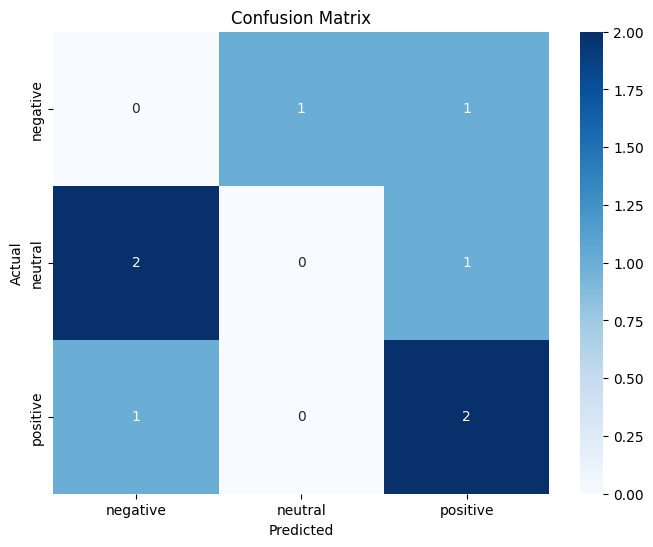

In [64]:
#By using Support Vector Machines (SVM) with TF-IDF vectorization, a combination well-suited for text classification tasks

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns #for advanced data vizualization

df_quotes['sentiment'] = ['positive', 'negative', 'neutral'] * (len(df_quotes) // 3) + ['positive'] * (len(df_quotes) % 3) #fix 2

# Prepare data
X = df_quotes['processed_text']
y = df_quotes['sentiment']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Feature extraction
vectorizer = TfidfVectorizer() #remove max_features
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Train model
svc_model = SVC(kernel='linear', C=1.0, random_state=42)
svc_model.fit(X_train_tfidf, y_train)

# Evaluate model
y_pred = svc_model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred, zero_division=1)) #add zero_division=1

# Visualize results
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=svc_model.classes_,
            yticklabels=svc_model.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()